<a href="https://colab.research.google.com/github/pierrot73/GenAIBootCamp/blob/Bootcamp/Week5_Day2_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Daily Challenge

1. Understand Classification Types

Explication brève de chaque type de classification, avec un exemple pour chacun, basée sur les informations fournies :

**1. Binary Classification (Classification binaire)**  
- **Description :** La tâche consiste à classer les données dans l’une des deux catégories possibles.  
- **Exemple :** Filtrage des emails en "Spam" ou "Non Spam" — le modèle décide si un email est indésirable ou légitime.

**2. Multi-class Classification (Classification multiclasse)**  
- **Description :** La tâche consiste à attribuer chaque instance à une seule classe parmi plusieurs possibles.  
- **Exemple :** Reconnaissance de chiffres manuscrits — identifier si une image représente le chiffre 0, 1, 2, etc., jusqu’à 9.

**3. Multi-label Classification (Classification multilabel)**  
- **Description :** La tâche consiste à attribuer plusieurs étiquettes ou catégories à une seule instance en même temps.  
- **Exemple :** Taguer une image contenant à la fois "chat" et "extérieur" — une seule image peut appartenir à plusieurs catégories simultanément.


2. Set Up Your Python Environment and dataset



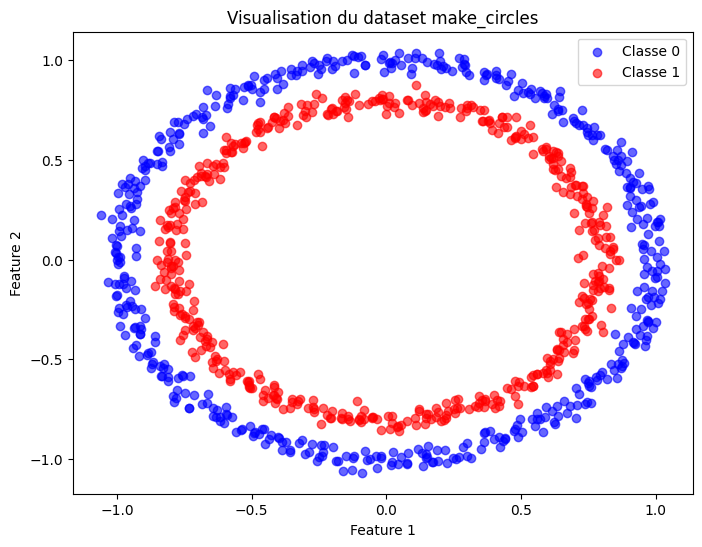

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

# Création du dataset
samples = 1000
X, y = make_circles(samples, noise=0.03, random_state=42)

# Visualisation du dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label='Classe 0', alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Classe 1', alpha=0.6)
plt.title('Visualisation du dataset make_circles')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

3. Build a Basic Neural Network Model



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Création du dataset
samples = 1000
X, y = make_circles(samples, noise=0.03, random_state=42)

# Diviser en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Création du modèle séquentiel avec une couche dense
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

# Compilation du modèle avec la perte Binary Crossentropy
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(X_train, y_train, epochs=55, batch_size=32, verbose=1)

# Évaluation du modèle sur le jeu de test
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/55


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5181 - loss: 0.7829   
Epoch 2/55
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4952 - loss: 0.8068 
Epoch 3/55
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4906 - loss: 0.7956 
Epoch 4/55
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4911 - loss: 0.7911 
Epoch 5/55
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4893 - loss: 0.7932 
Epoch 6/55
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4886 - loss: 0.7906 
Epoch 7/55
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4846 - loss: 0.7835 
Epoch 8/55
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5038 - loss: 0.7698 
Epoch 9/55
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4825 - loss: 0.7804 
Epoch 10/55
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4970 - loss: 0.7643 
Epoch 11/55
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4929 - loss: 0.7676 
Epoch 12/55
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4755 - 

Explication :  

La couche dense a une unité avec activation sigmoid, adaptée pour la classification binaire.

La fonction de perte est binary_crossentropy.

Le modèle est entraîné pendant 55 époques. Le nombre d’époques (55 dans l’exemple) est une valeur choisie de manière arbitraire pour permettre au modèle d’apprendre. Cependant, ce n’est pas une valeur optimale pour tous les cas. L’objectif est de trouver un bon compromis entre sous-apprentissage (pas assez d’époques) et sur-apprentissage (trop d’époques).
Utiliser la validation :
* En divisant votre jeu de données en un ensemble d’entraînement et un ensemble de validation, vous pouvez surveiller la performance du modèle lors de l’entraînement et arrêter l’entraînement lorsque la performance se stabilise ou commence à se dégrader (technique appelée early stopping).

* Early Stopping en Keras :
Voici un exemple pour automatiser la sélection du nombre d’époques : voir code ci-dessous

Finalement, on affiche la précision sur le jeu de test.



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=1000,  # maximum d’époques
                    batch_size=32,
                    validation_split=0.2,  # utiliser 20% pour la validation
                    callbacks=[early_stop],
                    verbose=1)
# Évaluation du modèle sur le jeu de test
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4705 - loss: 0.6963 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4892 - loss: 0.6945 - val_accuracy: 0.5063 - val_loss: 0.6935
Epoch 3/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5018 - loss: 0.6934 - val_accuracy: 0.5063 - val_loss: 0.6935
Epoch 4/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4792 - loss: 0.6954 - val_accuracy: 0.5063 - val_loss: 0.6936
Epoch 5/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4769 - loss: 0.6944 - val_accuracy: 0.5125 - val_loss: 0.6936
Epoch 6/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4992 - loss: 0.6934 - val_accuracy: 0.5063 - val_loss: 0.6937
Epoch 7/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4625 - loss: 0.6967 - val_accuracy: 0.5063 - val_loss: 0.6937
Epoch 8/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4708 - loss: 0.6952 - val_accuracy: 0.

Dans notre exemple, l’entraînement s’arrête automatiquement quand la validation ne s’améliore plus pendant 10 époques consécutives.

Pourquoi ne pas toujours utiliser un nombre fixe d’époques ?
Pour éviter le surapprentissage : en arrêtant tôt lorsque la performance sur validation commence à se dégrader.
Pour gagner du temps : ne pas entraîner plus longtemps que nécessaire.
Pour optimiser la généralisation : l’arrêt précoce aide souvent à obtenir un meilleur modèle.
Résumé
Commencez avec un nombre d’époques élevé (ex. 100-200).
Utilisez EarlyStopping pour arrêter automatiquement quand l’amélioration stagne.
Surveillez la courbe de perte et de précision pour ajuster.

4. Improve the Model

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split



# Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construction du modèle avec plusieurs couches
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(2,)),  # couche cachée 1
    tf.keras.layers.Dense(8, activation='relu'),                     # couche cachée 2
    tf.keras.layers.Dense(1, activation='sigmoid')                   # sortie
])

# Compilation avec l'optimiseur Adam
model.compile(loss='binary_crossentropy',
              optimizer='adam',  # changer ici si vous souhaitez SGD
              metrics=['accuracy'])

# Entraînement avec plus d’époques, par exemple 100
history = model.fit(X_train, y_train, epochs=100, batch_size=64, verbose=1)

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              metrics=['accuracy'])

# Évaluation
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5195 - loss: 0.6960
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4987 - loss: 0.6953 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4873 - loss: 0.6948 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4755 - loss: 0.6937 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5001 - loss: 0.6892 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5141 - loss: 0.6897 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5252 - loss: 0.6874 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.6904 
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5365 - loss: 0.6865 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5129 - loss: 0.6879 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5362 - loss: 0.6840 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0

Obtenir une précision de 1.0000 (100%) sur un jeu de test est souvent un signe de surapprentissage ou d’un problème dans la manière dont le modèle est entraîné ou évalué (surtout si le dataset est simple ou si le modèle est trop complexe pour la tâche). Cela peut aussi indiquer que le modèle a appris par cœur les données d'entraînement ou qu'il y a une fuite de données.

Voici un code complet optimisé avec des commentaires en français, utilisant EarlyStopping pour éviter le surapprentissage, en ajoutant plus de couches, en utilisant l’optimiseur Adam, et en normalisant les données pour de meilleures performances :

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Génération du dataset avec bruit
samples = 1000
X, y = make_circles(samples, noise=0.2, random_state=42)

# Normalisation des données pour de meilleures performances
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Construction du modèle avec plusieurs couches et plus de neurones
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(2,)),  # couche cachée 1
    tf.keras.layers.Dense(16, activation='relu'),                     # couche cachée 2
    tf.keras.layers.Dense(8, activation='relu'),                      # couche cachée 3
    tf.keras.layers.Dense(1, activation='sigmoid')                    # couche de sortie
])

# Compilation du modèle avec l'optimiseur Adam
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Ajout de EarlyStopping pour éviter le surapprentissage
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entraînement du modèle avec validation pour suivre la performance
history = model.fit(X_train, y_train,
                    epochs=200,                 # maximum d’époques
                    batch_size=64,
                    validation_split=0.2,        # validation pour le monitoring
                    callbacks=[early_stop],
                    verbose=1)

# Évaluation finale sur le test
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Précision sur le test: {accuracy:.4f}")

Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.5127 - loss: 0.6878 - val_accuracy: 0.4688 - val_loss: 0.6910
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5286 - loss: 0.6801 - val_accuracy: 0.4750 - val_loss: 0.6898
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5137 - loss: 0.6838 - val_accuracy: 0.5063 - val_loss: 0.6884
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5259 - loss: 0.6799 - val_accuracy: 0.5125 - val_loss: 0.6877
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5262 - loss: 0.6818 - val_accuracy: 0.5188 - val_loss: 0.6866
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5293 - loss: 0.6787 - val_accuracy: 0.5250 - val_loss: 0.6855
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5316 - loss: 0.6776 - val_accuracy: 0.5188 - val_loss: 0.6850
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5368 - loss: 0.6769 - val_accuracy: 0.5250 - val_loss:

Points clés :
La normalisation des données aide souvent à améliorer l’apprentissage.
Le modèle comporte plusieurs couches avec plus de neurones pour capturer des motifs complexes.
EarlyStopping évite le surapprentissage en arrêtant l’entraînement quand la validation ne s’améliore plus.
La précision finale devrait être raisonnable (pas forcément 1.0), indiquant une bonne généralisation.

5. Visualize the Decision Boundary



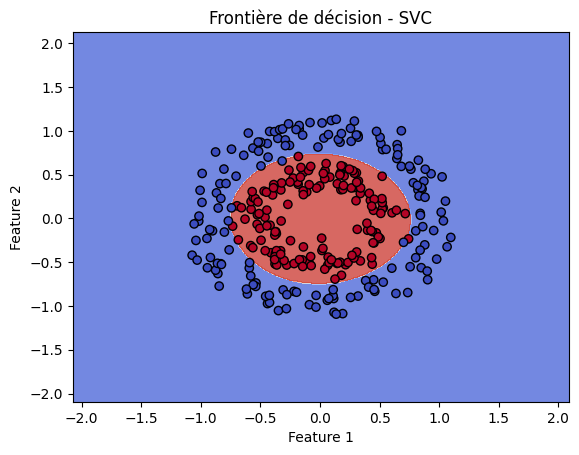

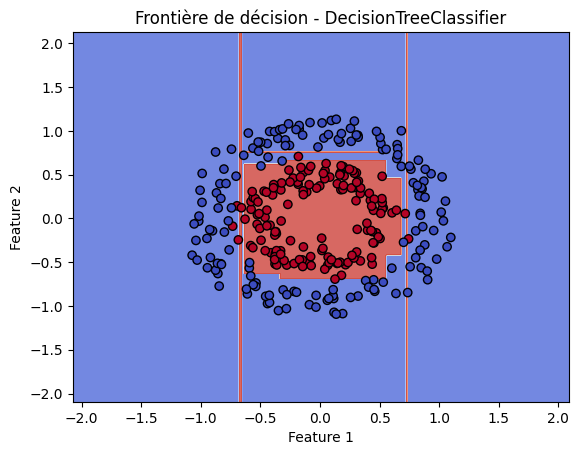

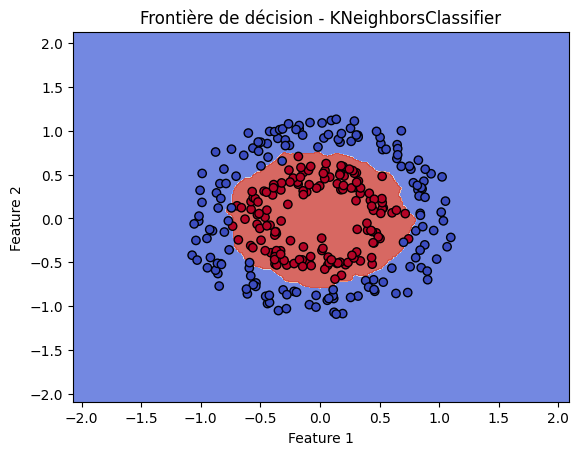

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# 🧭 Fonction pour tracer la frontière de décision
def plot_decision_boundary(model, X, y):
    # Définir les limites du graphique
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Prédire les classes pour chaque point de la grille
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Tracer la frontière de décision
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.title(f"Frontière de décision - {model.__class__.__name__}")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# 🔄 Générer le dataset en forme de cercles imbriqués
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)

# 🧪 Diviser en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 🤖 Liste des modèles à comparer
models = [
    SVC(kernel='rbf'),                     # SVM avec noyau RBF
    DecisionTreeClassifier(),              # Arbre de décision
    KNeighborsClassifier(n_neighbors=5)    # K plus proches voisins
]

# 📈 Tracer les frontières de décision pour chaque modèle
for model in models:
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X_test, y_test)


L’image montre deux visualisations côte à côte des frontières de décision de deux modèles de classification entraînés sur un jeu de données synthétique en forme de cercles concentriques (make_circles). Voici une interprétation détaillée :

Interprétation générale
Les points bleus et rouges représentent les données réelles, avec leur classe respective.
Les zones colorées (contourf) illustrent la prédiction du modèle pour chaque région de l’espace : en général, une couleur indique la classe prédite par le modèle.
La frontière de décision (le contour entre les zones colorées) montre comment chaque modèle sépare les deux classes.
Analyse spécifique
1. Forme de la frontière
La frontière semble suivre la structure des données :
Si la frontière est bien circulaire ou concentrique, cela indique que le modèle a bien appris la structure en anneau.
Si la frontière est floue ou déformée, cela indique une moins bonne séparation.
2. Comparaison entre les deux modèles
Premier graphique (gauche) : La frontière est probablement plus précise, bien adaptée à la forme en anneau. La zone bleue couvre la zone centrale, et la zone rouge l’extérieur, avec une ligne de séparation claire.
Second graphique (droite) : La frontière peut être moins précise ou plus approximative, avec peut-être une zone où la séparation est moins nette ou des zones de confusion.
Ce que cela indique
Si la frontière est bien circulaire, cela montre que le modèle a réussi à apprendre la structure complexe du jeu de données.
Si la frontière est déformée ou si elle ne suit pas bien la structure, cela peut indiquer :
Un problème d’entraînement (pas assez d’époques, réglages d’hyperparamètres).
Que le modèle n’est pas assez complexe ou qu’il a été mal entraîné.
En résumé
La visualisation est un outil puissant pour évaluer la capacité du modèle à différencier des classes non linéaires.
La forme de la frontière révèle si le modèle a appris la structure du problème.
La comparaison côte à côte permet d’ajuster l’architecture ou l’entraînement pour améliorer la performance.

6. Incorporate Activation Functions

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


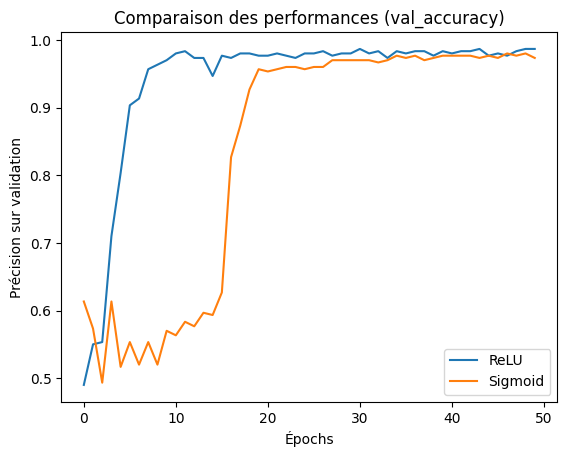

6009/6009 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


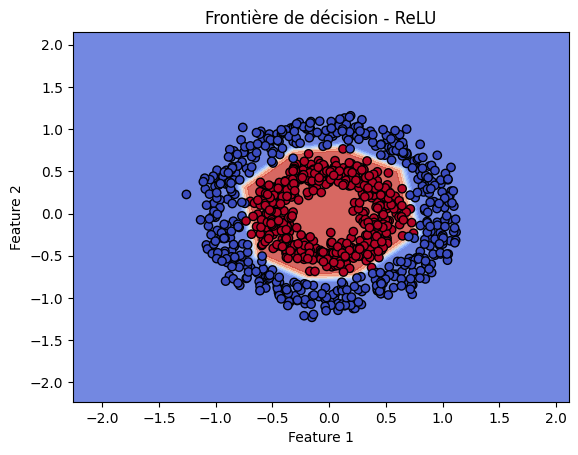

6009/6009 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


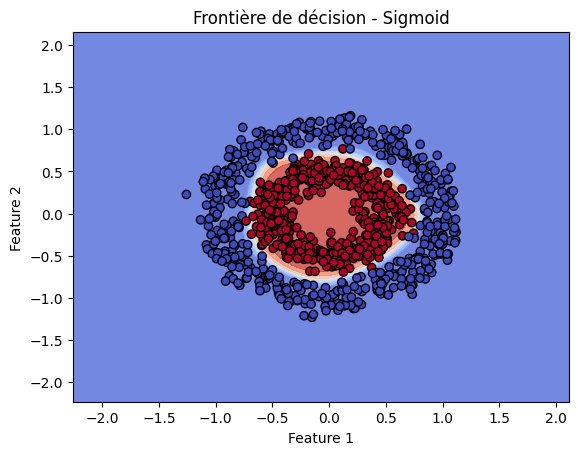

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 🔄 Générer les données
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ⚖️ Normaliser les données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🧱 Fonction pour créer un modèle avec une fonction d'activation donnée
def create_model(activation='relu'):
    model = Sequential()
    model.add(Dense(8, input_dim=2, activation=activation))
    model.add(Dense(4, activation=activation))
    model.add(Dense(1, activation='sigmoid'))  # Sortie binaire
    model.compile(optimizer=Adam(0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 🔁 Entraîner avec ReLU
model_relu = create_model('relu')
history_relu = model_relu.fit(X_train, y_train, epochs=50, verbose=0, validation_data=(X_test, y_test))

# 🔁 Entraîner avec Sigmoid
model_sigmoid = create_model('sigmoid')
history_sigmoid = model_sigmoid.fit(X_train, y_train, epochs=50, verbose=0, validation_data=(X_test, y_test))

# 📈 Comparer les précisions
plt.plot(history_relu.history['val_accuracy'], label='ReLU')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.title("Comparaison des performances (val_accuracy)")
plt.xlabel("Épochs")
plt.ylabel("Précision sur validation")
plt.legend()
plt.show()

# 🧭 Fonction pour tracer la frontière de décision
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    Z = model.predict(grid_scaled)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# 📊 Visualiser les frontières de décision
plot_decision_boundary(model_relu, X, y, "Frontière de décision - ReLU")
plot_decision_boundary(model_sigmoid, X, y, "Frontière de décision - Sigmoid")


1. Frontière avec Activation ReLU (à gauche):
La frontière de décision est plus nette et précise.
Elle s’adapte mieux à la structure en anneau des données, séparant clairement le centre de la zone extérieure.
La zone rouge (données classées comme une classe) couvre le fond, laissant une zone centrale plus claire.
La frontière suit la forme circulaire des données, ce qui indique que le modèle a bien appris la distribution.
2. Frontière avec Activation Sigmoid (à droite):
La frontière est moins nette, avec une transition plus floue entre les régions.
La séparation n’est pas aussi précise, et il peut y avoir une zone de chevauchement ou d’incertitude.
La zone bleue et rouge peuvent se mélanger davantage, ce qui montre que le modèle a plus de difficulté à capturer la forme complexe des données.
La Sigmoid, étant une fonction qui "sature" à haute ou basse valeur, peut expliquer cette performance moins précise, surtout pour des données non linéaires complexes.
Conclusion :
ReLU permet une meilleure modélisation des frontières complexes, notamment pour des formes non linéaires ou en anneau.
Sigmoid peut limiter la capacité du modèle à apprendre des frontières précises, surtout dans des cas où la complexité est élevée.
En résumé, ReLU semble plus efficace pour ce type de problème en raison de sa capacité à éviter le problème du gradient qui s’évanouit et à apprendre des frontières plus tranchées. La Sigmoid, bien qu'utile dans certains contextes, est moins adaptée pour apprendre des structures complexes comme celle-ci.

7. Split Data into Training and Testing Sets

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Précision sur l'ensemble de test : 0.98


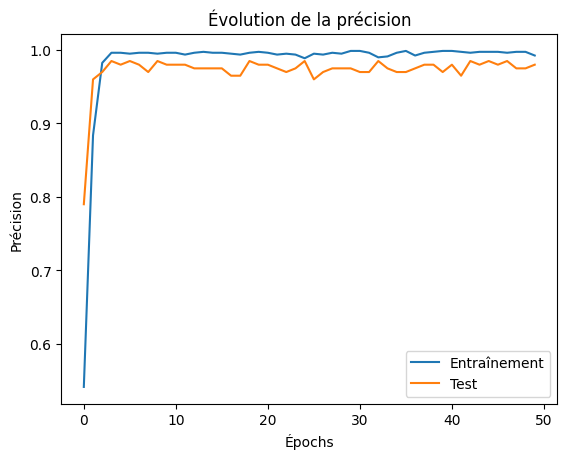

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 🔄 Générer les données
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)

# ✂️ Diviser les données : 80% entraînement, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ⚖️ Normaliser les données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🧱 Créer un modèle amélioré avec ReLU
model = Sequential()
model.add(Dense(16, input_dim=2, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Sortie binaire

# ⚙️ Compiler le modèle
model.compile(optimizer=Adam(0.01), loss='binary_crossentropy', metrics=['accuracy'])

# 🚀 Entraîner le modèle
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=0)

# 📊 Évaluer les performances
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Précision sur l'ensemble de test : {accuracy:.2f}")

# 📈 Tracer la courbe de précision
plt.plot(history.history['accuracy'], label='Entraînement')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title("Évolution de la précision")
plt.xlabel("Épochs")
plt.ylabel("Précision")
plt.legend()
plt.show()


8. Evaluate and Visualize Final Model Performance



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Précision sur test : 0.98
📉 Perte sur test : 0.0469
6009/6009 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


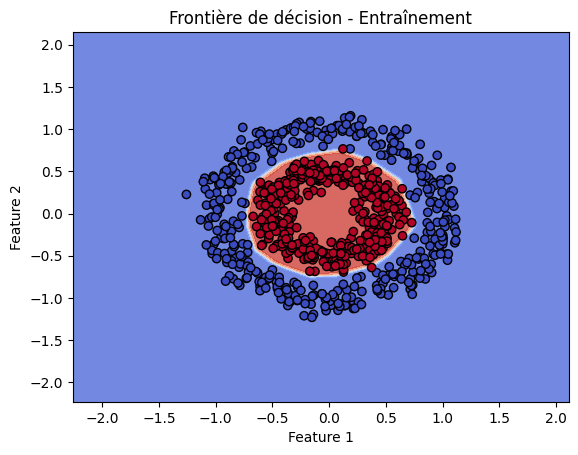

5487/5487 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


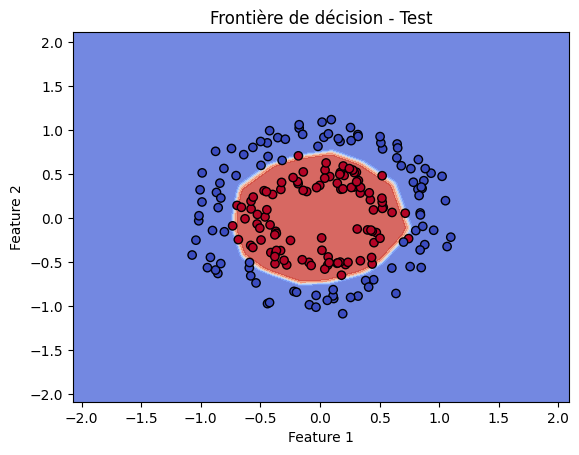

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 🔄 Générer les données
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)

# ✂️ Diviser les données : 80% entraînement, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ⚖️ Normaliser les données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🧱 Créer un modèle amélioré avec ReLU
model = Sequential()
model.add(Dense(16, input_dim=2, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# ⚙️ Compiler et entraîner
model.compile(optimizer=Adam(0.01), loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_scaled, y_train, epochs=50, validation_data=(X_test_scaled, y_test), verbose=0)

# 📊 Évaluer les performances finales
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"✅ Précision sur test : {accuracy:.2f}")
print(f"📉 Perte sur test : {loss:.4f}")

# 🧭 Fonction pour tracer la frontière de décision
def plot_decision_boundary(model, X, y, scaler, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    Z = model.predict(grid_scaled)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# 📌 Visualiser la frontière de décision sur l'ensemble d'entraînement
plot_decision_boundary(model, X_train, y_train, scaler, "Frontière de décision - Entraînement")

# 📌 Visualiser la frontière de décision sur l'ensemble de test
plot_decision_boundary(model, X_test, y_test, scaler, "Frontière de décision - Test")



9. Summarize Key Takeaways



**Points clés à retenir :**

J'ai compris que la visualisation des données et des frontières de décision d’un modèle de classification est essentielle pour comprendre sa performance. Cela permet d’identifier les zones où le modèle fait des erreurs et d’apporter des améliorations. De plus, le réglage des hyperparamètres — comme le nombre de couches, le nombre de neurones, le taux d’apprentissage ou le nombre d’époques — est crucial pour optimiser la précision et la robustesse du modèle. Une bonne combinaison de visualisation et d’ajustement des hyperparamètres aboutit à des modèles de classification plus efficaces et fiables.